                              OLS Regression Results                              
Dep. Variable:     individual_consumption   R-squared:                       0.978
Model:                                OLS   Adj. R-squared:                  0.978
Method:                     Least Squares   F-statistic:                 1.784e+06
Date:                    Thu, 03 Apr 2025   Prob (F-statistic):               0.00
Time:                            14:08:03   Log-Likelihood:                -86431.
No. Observations:                  122687   AIC:                         1.729e+05
Df Residuals:                      122683   BIC:                         1.729e+05
Df Model:                               3                                         
Covariance Type:                nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const     

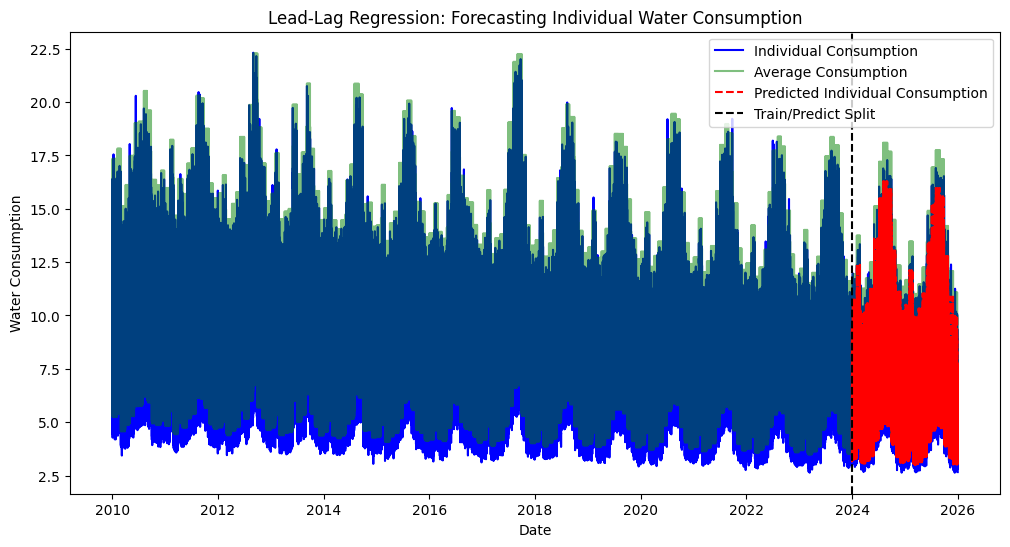

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Load the CSV data
# (Make sure your CSV file has at least 'timestamo' and 'water_usage' columns.)
df = pd.read_csv("../expanded_water_usage.csv", parse_dates=["timestamp"])

# Create an "individual_consumption" curve: similar trend, but shifted downwards and randomized.
# Here we multiply by 0.9 to shift downward and add noise scaled to 5% of the average value.
df['individual_consumption'] = df['water_usage'] * 0.9 + np.random.normal(
    loc=0, scale=0.05 * df['water_usage'], size=len(df))

# For demonstration, assume the individual's consumption is only observed until the end of 2023.
cutoff_date = pd.Timestamp("2023-12-31")
train_df = df[df['timestamp'] <= cutoff_date].copy()
predict_df = df[df['timestamp'] > cutoff_date].copy()

# Create lag and lead features for the average consumption in the training data.
# Here we use a lag of 1 and a lead of 1 (i.e. previous and next day) as example predictors.
train_df['avg_lag1'] = train_df['water_usage'].shift(1)
train_df['avg_lead1'] = train_df['water_usage'].shift(-1)

# Drop rows with missing values (which occur at the start/end due to shifting).
train_df = train_df.dropna()

# Define independent variables (features) and dependent variable.
X_train = train_df[['water_usage', 'avg_lag1', 'avg_lead1']]
y_train = train_df['individual_consumption']

# Add a constant (intercept) to the predictors.
X_train = sm.add_constant(X_train)

# Fit an OLS regression model.
model = sm.OLS(y_train, X_train).fit()
print(model.summary())

# Prepare the prediction dataset with the same lead and lag features.
predict_df['avg_lag1'] = predict_df['water_usage'].shift(1)
predict_df['avg_lead1'] = predict_df['water_usage'].shift(-1)
predict_df = predict_df.dropna()  # remove any NaNs due to shifting

X_predict = predict_df[['water_usage', 'avg_lag1', 'avg_lead1']]
X_predict = sm.add_constant(X_predict)
predict_df['predicted_individual'] = model.predict(X_predict)

# Plot the original average consumption, the simulated individual consumption,
# and the predicted individual consumption for the period beyond the cutoff.
plt.figure(figsize=(12,6))
plt.plot(df['timestamp'], df['individual_consumption'], label="Individual Consumption", color='blue')
plt.plot(df['timestamp'], df['water_usage'], label="Average Consumption", alpha=0.5, color='green')
plt.plot(predict_df['timestamp'], predict_df['predicted_individual'], 
         label="Predicted Individual Consumption", linestyle="--", color='red')
plt.axvline(cutoff_date, color='black', linestyle='--', label='Train/Predict Split')
plt.xlabel("Date")
plt.ylabel("Water Consumption")
plt.title("Lead-Lag Regression: Forecasting Individual Water Consumption")
plt.legend()
plt.show()


                              OLS Regression Results                              
Dep. Variable:     individual_consumption   R-squared:                       0.972
Model:                                OLS   Adj. R-squared:                  0.972
Method:                     Least Squares   F-statistic:                 1.406e+06
Date:                    Thu, 03 Apr 2025   Prob (F-statistic):               0.00
Time:                            14:07:51   Log-Likelihood:                -86681.
No. Observations:                  122687   AIC:                         1.734e+05
Df Residuals:                      122683   BIC:                         1.734e+05
Df Model:                               3                                         
Covariance Type:                nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const     

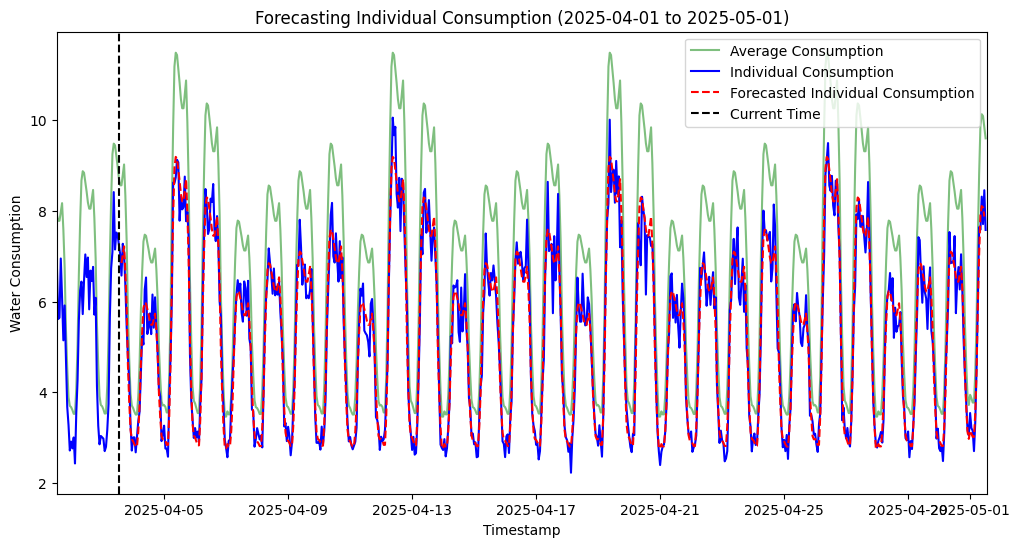

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm



# ---- Usage Example ----

# Load the CSV data (ensure the CSV file has 'timestamp' and 'water_usage' columns)
df = pd.read_csv("../expanded_water_usage.csv", parse_dates=["timestamp"])

# Create an individual consumption series: shift downward by 10% and add noise (5% scaled noise)
df['individual_consumption'] = df['water_usage'] * 0.8 + np.random.normal(
    loc=0, scale=0.05 * df['water_usage'], size=len(df))

# For training the model, assume we only have individual data up to the end of 2023.
cutoff_date = pd.Timestamp("2023-12-31")
train_df = df[df['timestamp'] <= cutoff_date].copy()

# Create lag and lead features in the training data
train_df['avg_lag1'] = train_df['water_usage'].shift(1)
train_df['avg_lead1'] = train_df['water_usage'].shift(-1)
train_df = train_df.dropna()

# Define predictors and response
X_train = train_df[['water_usage', 'avg_lag1', 'avg_lead1']]
y_train = train_df['individual_consumption']
X_train = sm.add_constant(X_train)

# Fit the OLS regression model
model = sm.OLS(y_train, X_train).fit()
print(model.summary())

# Choose current time for forecast (example: April 3, 2025 at 1 PM)
current_time = pd.Timestamp("2025-04-03 13:00:00")

# Get the forecast for a specific granularity, e.g., 'daily'
result, period_start, period_end = forecast_period(df, model, granularity='monthly', current_time=current_time)

# Plot only the selected period.
# Filter the original DataFrame for the selected period.
df_period = df[(df['timestamp'] >= period_start) & (df['timestamp'] <= period_end)]

plt.figure(figsize=(12,6))
plt.plot(df_period['timestamp'], df_period['water_usage'], label="Average Consumption", alpha=0.5, color='green')
plt.plot(df_period['timestamp'], df_period['individual_consumption'], label="Individual Consumption", color='blue')
plt.plot(result['timestamp'], result['forecast'], label="Forecasted Individual Consumption", linestyle="--", color='red')
plt.axvline(current_time, color='black', linestyle='--', label='Current Time')
plt.xlabel("Timestamp")
plt.ylabel("Water Consumption")
plt.title(f"Forecasting Individual Consumption ({period_start.date()} to {period_end.date()})")
plt.legend()
plt.xlim(period_start, period_end)
plt.show()


In [ ]:
def forecast_period(data, model, granularity='daily', current_time=None):

    if current_time is None:
        current_time = pd.Timestamp.now()

    # Define period boundaries based on granularity.
    if granularity == 'daily':
        period_start = current_time.normalize()  # midnight of the current day
        period_end = period_start + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)
    elif granularity == 'monthly':
        period_start = current_time.replace(day=1)
        next_month = period_start + pd.offsets.MonthBegin(1)
        period_end = next_month - pd.Timedelta(seconds=1)
    elif granularity == 'yearly':
        period_start = pd.Timestamp(year=current_time.year, month=1, day=1)
        period_end = pd.Timestamp(year=current_time.year, month=12, day=31, hour=23, minute=59, second=59)
    else:
        raise ValueError("Invalid granularity. Choose 'daily', 'monthly', or 'yearly'.")

    # Filter the data for the selected period.
    period_data = data[(data['timestamp'] >= period_start) & (data['timestamp'] <= period_end)].copy()
    
    # Split into historical (up to current_time) and future (after current_time)
    historical = period_data[period_data['timestamp'] <= current_time].copy()
    future = period_data[period_data['timestamp'] > current_time].copy()

    # For the future segment, create lag and lead features for 'water_usage'
    future['avg_lag1'] = future['water_usage'].shift(1)
    future['avg_lead1'] = future['water_usage'].shift(-1)
    future = future.dropna()  # Remove boundary NaNs

    # Prepare predictor variables for forecasting
    X_future = future[['water_usage', 'avg_lag1', 'avg_lead1']]
    X_future = sm.add_constant(X_future)

    # Generate forecasts using the provided model
    future['forecast'] = model.predict(X_future)

    # Mark historical data with no forecast
    historical['forecast'] = np.nan

    # Combine historical and forecasted data within the period
    combined = pd.concat([historical, future]).sort_values('timestamp')
    
    return combined, period_start, period_end

In [ ]:
import pickle
import statsmodels.api as sm

# After training your model (assume 'model' is your trained OLS model)
with open("ols_model.pkl", "wb") as file:
    pickle.dump(model, file)
    
with open("ols_model.pkl", "rb") as file:
    model1 = pickle.load(file)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pickle



with open("ols_model.pkl", "rb") as file:
    model1 = pickle.load(file)

In [5]:
current_time = pd.Timestamp("2025-08-02 13:00:00")

result, period_start, period_end = forecast_period(df, model1, granularity='yearly', current_time=current_time)


# Plot only the selected period.
# Filter the original DataFrame for the selected period.


df_period = df[(df['timestamp'] >= period_start) & (df['timestamp'] <= period_end)]

plt.figure(figsize=(12,6))
plt.plot(df_period['timestamp'], df_period['water_usage'], label="Average Consumption", alpha=0.5, color='green')
plt.plot(df_period['timestamp'], df_period['individual_consumption'], label="Individual Consumption", color='blue')
plt.plot(result['timestamp'], result['forecast'], label="Forecasted Individual Consumption", linestyle="--", color='red')
plt.axvline(current_time, color='black', linestyle='--', label='Current Time')
plt.xlabel("Timestamp")
plt.ylabel("Water Consumption")
plt.title(f"Forecasting Individual Consumption ({period_start.date()} to {period_end.date()})")
plt.legend()
plt.xlim(period_start, period_end)
plt.show()



NameError: name 'df' is not defined

In [16]:
df.head()

df_filtered = df[(df['timestamp'].dt.year>2024)]

df_filtered.head()


df_filtered.to_csv("projection_data.csv", index=False)



In [11]:
df_old =  pd.read_csv("../1_year_data.csv", parse_dates=["timestamp"])

df_old.head()


,index,timestamp,flow_rate,day_type,month,temperature,purity
0,0,2024-01-01 00:00:00,2.312,Weekday,1,-6.10,88.67
1,1,2024-01-01 00:01:00,3.006,Weekday,1,-4.86,88.67
2,2,2024-01-01 00:02:00,3.797,Weekday,1,-4.79,88.67
3,3,2024-01-01 00:03:00,3.229,Weekday,1,-5.20,88.67
4,4,2024-01-01 00:04:00,3.817,Weekday,1,-5.05,88.67


In [12]:
df_old.shape,df_filtered.shape

((592995, 7), (17544, 3))

In [20]:
df.head()
df.to_csv("expanded_calgary_data.csv", index=False)